In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

import sklearn
sklearn.set_config(display='text')
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # 회귀 문제 성능 평가
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report # 분류 문제 성능 평가
from sklearn.metrics import silhouette_score # 실루엣 스코어 알고리즘을 사용하기 위해 import 한다. 군집 문제 성능 평가

from sklearn.cluster import KMeans # k 평균 클러스터링 알고리즘을 사용하기 위해 import 한다.

지도 학습에서는 라벨링된 데이터를 이용해서 모델을 생성한다. 주어진 데이터셋에 라벨링이 되어 있다면 학습 및 분류를 시키기 좋지만 실제 데이터를 다루다 보면 라벨링이 되어있지 않은 경우도 많이 접한다. 비지도 학습은 라벨링이 되어있지 않은 데이터를 이용하는 학습 방법이다.

비지도 학습에 사용하는 데이터는 라벨링이 되어있지 않으므로 레이블 없이 피쳐 데이터만 활용해서 데이터를 학습시킨다. 지도 학습에서는 데이터를 분류하는 것을 classification라고 했지만, 비지도 학습에서는 데이터를 분류하는 것을 clustering이라고 한다.

k평균 클러스터링(KMeans clustering)

k평균 클러스터링은 $n$개의 데이터를 $k$개의 클러스터로 나누는 클러스터링 기법이다. k평균 클러스터링은 각 데이터 포인트와 각 그룹의 평균(중심)간의 거리를 구한 후 가장 가까운 클러스터로 배정하는 방법이다.

k평균 클러스터링에서는 거리라는 개념이 사용되고 여기서는 유클리드 거리(euclidean distance)를 사용한다. 데이터 포인트 $x$와 데이터 포인트 $y$ 사이의 유클리드 거리는 아래와 같은 공식을 사용한다.

$$d(x, y) = \sqrt {\sum_{i=1}^n (x_i - y_i)^2}$$

k평균 클러스터링 알고리즘  
① `그룹 평균 초기화`  
&nbsp;&nbsp;&nbsp;k평균 클러스터링 알고리즘의 첫 과정은 각 그룹의 평균을 초기화하는 것인데, 이때 사용하는 가장 기본적인 방법은 랜덤으로 평균(중심)을 설정하는 것이다.  
② `그룹 할당`  
&nbsp;&nbsp;&nbsp;각 데이터 포인트와 가장 가까운 그룹 평균에 해당되는 그룹에 할당한다. 각 데이터 포인트와 각 그룹의 평균까지의 거리를 계산해서 가장 가까운 그룹에 속하게 한다.  
③ `평균 업데이트`  
&nbsp;&nbsp;&nbsp;위 ② 단계를 거치면 모든 데이터 포인트가 어떤 그룹에 속하는지 알 수 있다. 그 후 각 그룹에 대한 새로운 평균값을 계산한다.  
④ `반복`  
&nbsp;&nbsp;&nbsp;② 단계에서 바뀌는 값이 없을 때 까지 ② ~ ③ 단계를 반복한다.

k평균 클러스터링은 사용하기 쉽다는 장점이 있지만 k평균 클러스터링에서는 가중치를 주지않아 클러스터간 데이터의 밀도 차이가 있을 경우 클러스터링이 잘되지 않는 단점이 있다. 그리고 k평균 클러스터링은 데이터들이 배치되는 모양을 고려하지 않으며, 초기 k값을 사용자가 지정해야 한다는 단점이 있다.

데이터 불러오기

make_blobs() 메소드로 사이킷런이 제공하는 모든 방향을 같은 성질을 가지는 등방성 가우시안 정규 분포를 따르는 데이터를 랜덤하게 만들어준다.  
n_samples 속성의 기본값은 100이고 랜덤하게 만들 데이터 개수를 지정한다.  
n_features 속성의 기본값은 2이고 데이터당 피쳐의 개수를 지정한다.  
centers 속성은 클러스터의 개수를 설정해서 클러스터링용 가상 데이터를 만든다.

In [2]:
x_train, y_train = datasets.make_blobs(n_samples=100, n_features=2, centers=6, random_state=10)
print(x_train.shape, y_train.shape)

for i in range(len(x_train))[:5]:
    print(x_train[i], y_train[i])

(100, 2) (100,)
[-6.08678403  4.7298269 ] 3
[3.80174985 4.27826762] 1
[-7.33058271 -8.4940632 ] 4
[-6.10706886 -7.81890608] 4
[ 5.52556208 -8.18696464] 0


클러스터링 되지 않은 데이터 시각화

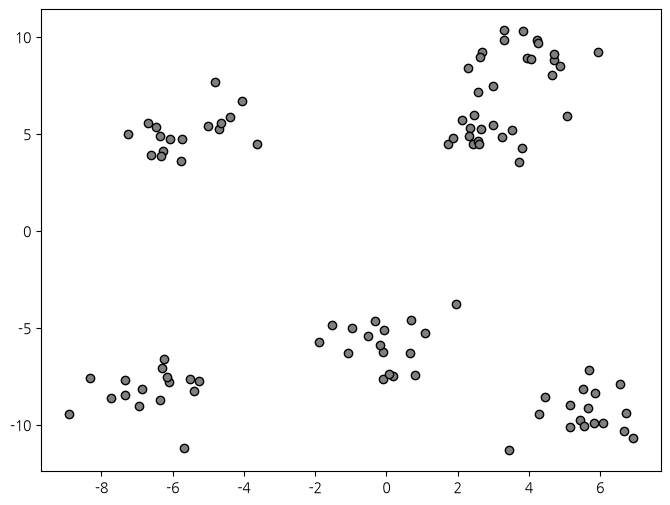

In [3]:
plt.figure(figsize=[8, 6])
plt.scatter(x_train[:, 0], x_train[:, 1], c='gray', edgecolors='black', marker='o')
plt.show()

k평균 클러스터링 모델 생성 후 데이터 학습

In [4]:
# n_clusters 속성에 클러스터 개수, init 속성에 첫 번째 중심값은 선정하는 방법, max_iter 속성에 최대 반복횟수를 지정해서 k평균 클러스터 모델을 만든다.
model = KMeans(n_clusters=6, init='random', max_iter=100, random_state=0)
# k평균 클러스터링은 비지도 학습이므로 학습 데이터만 넘겨서 모델을 학습시킨다.
model.fit(x_train)

KMeans(init='random', max_iter=100, n_clusters=6, random_state=0)

In [5]:
# 클러스터링 결과를 확인한다.
# labels_ 속성으로 클러스터링 결과를 확인할 수 있다.
print(model.labels_)
# predict() 메소드에 피쳐 데이터를 넘겨서 예측하면 클러스터링 결과와 같은 결과가 나온다.
print(model.predict(x_train))

[2 1 3 3 4 3 5 5 4 2 0 3 4 2 4 3 1 5 4 5 5 3 2 3 3 3 2 0 4 5 5 2 2 4 2 2 1
 1 2 0 5 5 0 5 4 0 0 2 4 1 4 1 4 2 0 4 4 2 1 5 3 1 1 5 2 3 1 1 1 4 0 0 3 5
 4 3 2 2 0 5 2 3 3 4 4 0 5 1 0 5 0 5 0 1 0 3 1 1 1 0]
[2 1 3 3 4 3 5 5 4 2 0 3 4 2 4 3 1 5 4 5 5 3 2 3 3 3 2 0 4 5 5 2 2 4 2 2 1
 1 2 0 5 5 0 5 4 0 0 2 4 1 4 1 4 2 0 4 4 2 1 5 3 1 1 5 2 3 1 1 1 4 0 0 3 5
 4 3 2 2 0 5 2 3 3 4 4 0 5 1 0 5 0 5 0 1 0 3 1 1 1 0]


k평균 클러스터링 알고리즘으로 클러스터링 된 데이터 시각화

In [6]:
# 클러스터링된 데이터를 시각화 하기 위해서 데이터프레임으로 만든다.
df = pd.DataFrame(x_train, columns=['x', 'y'])
df['label'] = y_train # make_blobs() 메소드가 실행될 때 설정된 중심
df['cluster'] = model.labels_ # k평균 클러스터링 알고리즘으로 클러스터링된 중심
df

,x,y,label,cluster
0,-6.086784,4.729827,3,2
1,3.801750,4.278268,1,1
2,-7.330583,-8.494063,4,3
3,-6.107069,-7.818906,4,3
4,5.525562,-8.186965,0,4
...,...,...,...,...
95,-6.950884,-9.024594,4,3
96,2.591843,4.446782,1,1
97,2.992321,5.436981,1,1
98,2.310466,4.854172,1,1


In [7]:
# make_blobs() 메소드가 만들어준 레이블과 k평균 클러스터링 알고리즘으로 클러스터링된 레이블의 종류 확인
print(set(df.label), set(df.cluster))

{0, 1, 2, 3, 4, 5} {0, 1, 2, 3, 4, 5}


make_blobs() 메소드가 만들어준 레이블별 시각화

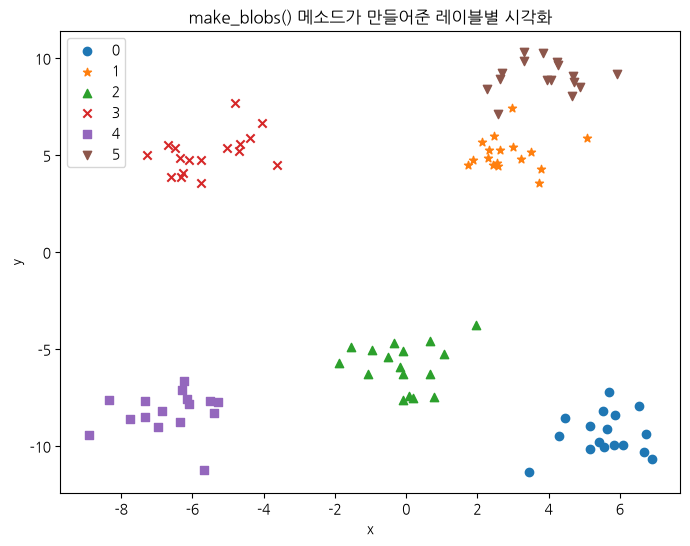

In [8]:
plt.figure(figsize=[8, 6])
markers = ['o', '*', '^', 'x', 's', 'v']

for index, marker in enumerate(markers):
    df_index = df[df.label == index]
    plt.scatter(x=df_index.x, y=df_index.y, marker=marker, label=index)

plt.title('make_blobs() 메소드가 만들어준 레이블별 시각화')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

k평균 클러스터링 알고리즘으로 클러스터링한 클러스터별 시각화

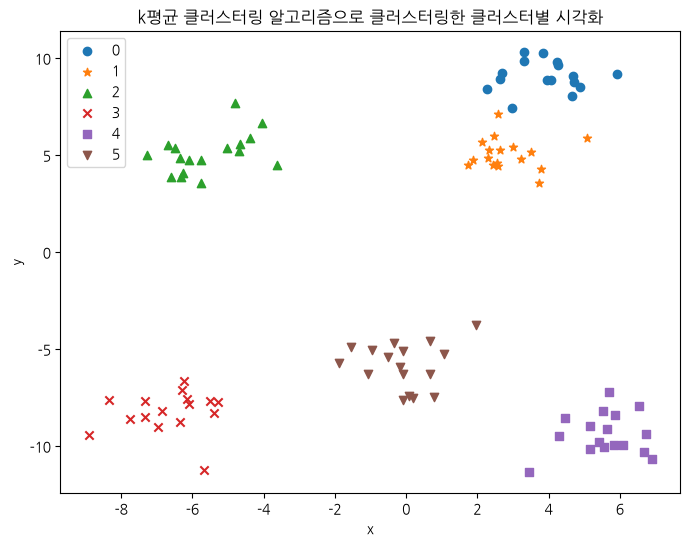

In [9]:
plt.figure(figsize=[8, 6])
markers = ['o', '*', '^', 'x', 's', 'v']

for index, marker in enumerate(markers):
    df_index = df[df.cluster == index]
    plt.scatter(x=df_index.x, y=df_index.y, marker=marker, label=index)

plt.title('k평균 클러스터링 알고리즘으로 클러스터링한 클러스터별 시각화')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

학습된 모델을 평가한다.

In [11]:
# 실루엣 스코어(silhouette score)는 서로 다른 군집이 얼마나 잘 분리되어 있는지를 나타내는 평가 지표로서 군집 문제에서 모델 성능을 평가한다.
# 실루엣 스코어는 -1 ~ 1 사이의 값을 가지며 점수가 높을수록 좋은 성능임을 의미한다.
# silhouette_score() 함수에 피쳐(x_train)와 군집화 결과로 얻은 클러스터(model.labels_)를 넘겨서 실루엣 스코어를 계산한다.
sil_score = silhouette_score(x_train, model.labels_)
print(sil_score)

0.7004453149145585
